In [1]:
freq = 50
import os

In [2]:
#do dummy-check :P (check wether downsampling frequency of the two scripts match)
with open("np_data_downsampler.py", "r") as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        if "target_fs = " in line:
            tf = int(line.split("=")[1].split("#")[0].strip())
            if tf != freq:
                print("Error: target_fs = {} in line {} is not equal to freq = {}".format(tf, i, freq))
                exit(1)
            break

In [3]:
#checks whether data exists. If not, run downsampler
in_data = os.listdir("prepped_data")
dataExists = False
for file in in_data:
    if file.endswith(".npy"):
        dataExists = True
        break
if not dataExists:
    os.system("python3 np_data_downsampler.py")


# step 1: Load and visuallize the ingoing datastream

nanmask: 0


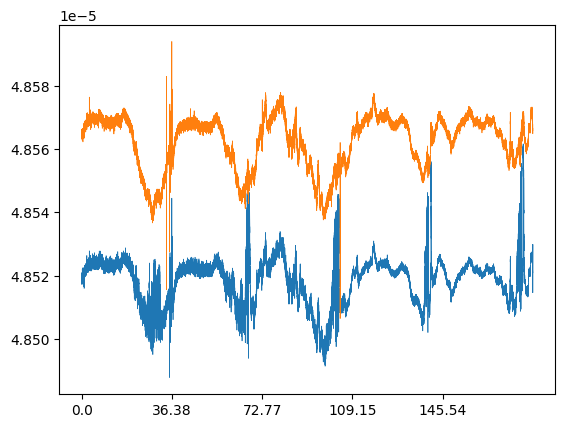

In [4]:

import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import gc
from natsort import natsorted
gc.collect()

def load_all_downsampled_data(path):
    files = natsorted([f for f in os.listdir(path) if f.endswith('.npy')])
    all_data = [np.load(os.path.join(path, file)) for file in files]
    return np.hstack(all_data)

data_channels = load_all_downsampled_data('prepped_data')#!temp: i believe the data is in nanoTesla

#dump the first 1500ths of the data
data_channels = data_channels[:,len(data_channels[0])//1500:]

nanmask = np.isnan(data_channels)
print(f"nanmask: {np.sum(nanmask)}")
del nanmask


gc.collect()
#plot every tenth data point to check
plt.plot(data_channels[0],linewidth=0.5)
plt.plot(data_channels[1],linewidth=0.5)
#set ticks
plt.xticks(
    np.arange(0, len(data_channels[0]), len(data_channels[0])/5),
    np.round(np.arange(0, len(data_channels[0]), len(data_channels[0])/5)/freq/60/60,2)
    )
plt.savefig("data_chan1.png")
plt.show()

# step 1.5: Data combination
Temporarilly, this will be done with the asusmption that each sensor is approximately on the same longitude-lattitude point, as their seperation will be small as compared to the VSH wavelength


100%|██████████| 250/250 [00:20<00:00, 11.99it/s]


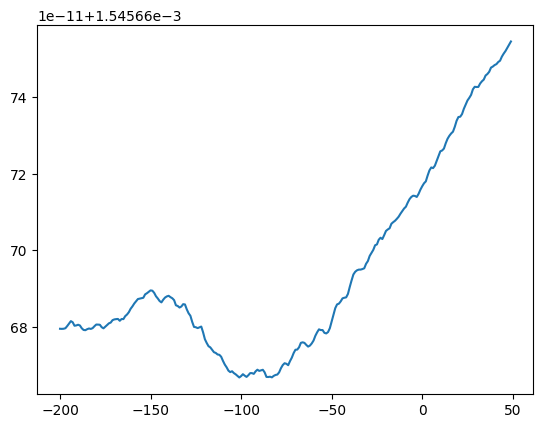

shift: -101


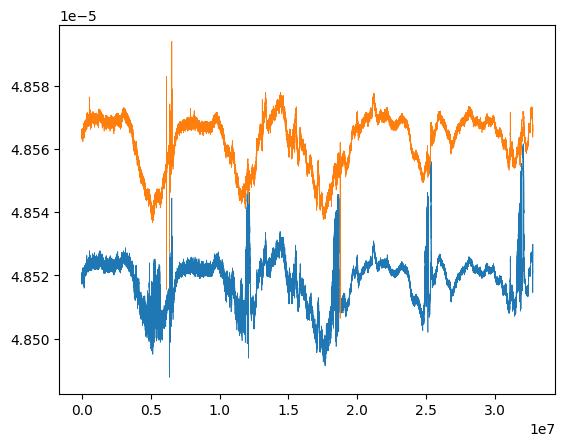

In [6]:
#1, find an optimal timeshift for the datapoints to allign
#1.1 supersample the datastream by a factor of two
def supersampled_dotproduct(a,b, factor=2):
    #a and b are assumed to be of equal length
    sum = 0
    for i in range(0, len(a), 100000):#do this chukwise to save memory
        a_chunk = a[i:i+1000]
        b_chunk = b[i:i+1000]
        a_chunk = np.interp(np.linspace(0, 1, len(a_chunk)*factor), np.linspace(0, 1, len(a_chunk)), a_chunk)
        b_chunk = np.interp(np.linspace(0, 1, len(b_chunk)*factor), np.linspace(0, 1, len(b_chunk)), b_chunk)
        sum += np.dot(a_chunk, b_chunk)
    return sum

shifts = np.arange(-200,50,1)
dotproducts = np.zeros(len(shifts))
for i, shift in enumerate(tqdm(shifts)):
    dotproducts[i] = supersampled_dotproduct(data_channels[0], np.roll(data_channels[1], shift))

plt.plot(shifts, dotproducts)
plt.savefig("dotproducts.png")
plt.show()

shift = shifts[np.argmin(dotproducts)]
print(f"shift: {shift}")

#1.2 apply the shift
data_channels[1] = np.roll(data_channels[1], shift)

#2 add data
data_combined = np.sqrt(data_channels[0]**2 + data_channels[1]**2)
plt.plot(data_channels[0],linewidth=0.5)
plt.plot(data_channels[1],linewidth=0.5)
plt.show()


# step 2: perform the fourier transform on the datastream.


infintete msas: 0
nanmask: 0


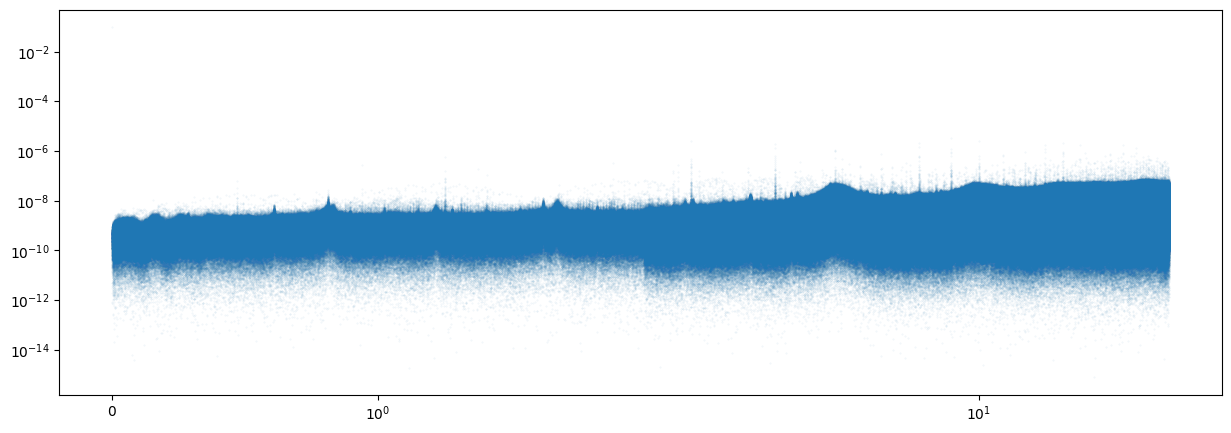

In [7]:
try:
    s = np.load("temp/X_shape.npy")
    data_frequential = np.load('temp/F_transform.npy',mmap_mode='r+')
    freqs = np.load('temp/X_freqs.npy')
except:

    data_frequential = data_combined

    from scipy import fft

    num_samples = data_frequential.shape[0]
    sample_rate = freq
    duration = num_samples/sample_rate
    
    #do fft
    data_frequential = fft.fft(data_frequential,workers=-1)

    freqs = np.fft.fftfreq(num_samples,d=1/freq)
    freq_ref = np.fft.fftfreq(num_samples,d=1)

    #add the negative side of the spectrum to the positive side
    posmask = freqs>0
    negmask = freqs<0
    data_frequential = data_frequential[posmask] + np.flip(data_frequential[negmask],axis=0)
    freqs = freqs[posmask]
    freq_ref = freq_ref[posmask]

    #put the frequencie in the fourier transform
    freq_ratio = freq_ref/freq
    data_frequential[1:] = data_frequential[1:]*freq_ratio[1:]


    np.save('temp/F_transform.npy',data_frequential)
    np.save('temp/F_transform_freqs.npy',freqs)
    print(data_frequential[0])
    s = data_frequential.shape
    del data_frequential

    data_frequential = np.load('temp/F_transform.npy',mmap_mode='r+')
    print(data_frequential[0])

    np.save("temp/F_transform_shape.npy",s)


duration = data_frequential.shape[0]/freq
mask = np.isfinite(freqs)
print(f"infintete msas: {np.sum(~mask)}")
del data_combined
datlen = len(data_frequential)

nanmask = np.isnan(data_frequential)
print(f"nanmask: {np.sum(nanmask)}")
del nanmask

#display X as frequency domain
fig,ax = plt.subplots(figsize=(15,5))
plt.scatter(freqs,np.abs(data_frequential),s=0.1,alpha=0.1)
plt.loglog()
plt.xscale('symlog')
plt.yscale('log')
plt.show()



# step 2.5: compose data signature vector

#first find the dirrectional projections
#then produce three vectors, with pointers to the offset frequency components.

Temporarily, alpha is set to 0

In [8]:
#do the 15 X projections
alpha = 0
phi = 0.25394666280223638935969239187245
theta = 0.82931467908819774867238359928072#!temp just of austria
projection_coffs = []
projection_coffs.append(np.sin(phi)*np.cos(alpha))
projection_coffs.append(np.cos(phi)*np.cos(alpha))
projection_coffs.append(np.cos(phi)*np.cos(theta)*np.sin(alpha))
projection_coffs.append(-np.sin(phi)*np.cos(theta)*np.sin(alpha))
projection_coffs.append(np.sin(theta)*np.sin(alpha))

f_d = 1.1574074074074074074074074074074e-5

down_shift_mask = np.full(len(freqs),-1)
up_shift_mask = np.full(len(freqs),-1)
unity_mask = np.full(len(freqs),-1)
max_freq_err = 0
for i in tqdm(range(len(freqs)),desc="finding shift masks"):
    
    abs_err_down = np.abs(freqs[i]-f_d - freqs[i-min(9,i):i+1])
    abs_err_up = np.abs(freqs[i]+f_d - freqs[i:min(i+10,len(freqs))])
    if len(abs_err_down) == 0 or len(abs_err_up) == 0:
        continue
    down_shift_mask[i] = i-np.argmin(abs_err_down[::-1])
    up_shift_mask[i] = i+np.argmin(abs_err_up)
    unity_mask[i] = i
    if i % 1000000 == 0:
        print(f"upshift: {up_shift_mask[i]-i}, downshift: {down_shift_mask[i]-i}")

#remove the -1s
down_shift_mask = down_shift_mask[down_shift_mask != -1]
up_shift_mask = up_shift_mask[up_shift_mask != -1]
unity_mask = unity_mask[unity_mask != -1]

finding shift masks:   0%|          | 29340/16373077 [00:00<01:51, 146785.05it/s]

upshift: 8, downshift: 0


finding shift masks:   6%|▌         | 1016771/16373077 [00:06<01:42, 149167.11it/s]

upshift: 8, downshift: -8


finding shift masks:  12%|█▏        | 2024137/16373077 [00:13<01:37, 146865.45it/s]

...

finding shift masks:  92%|█████████▏| 15027647/16373077 [01:43<00:09, 143368.27it/s]

upshift: 8, downshift: -8


finding shift masks:  98%|█████████▊| 16015744/16373077 [01:50<00:02, 144154.24it/s]

upshift: 8, downshift: -8


finding shift masks: 100%|██████████| 16373077/16373077 [01:52<00:00, 145426.27it/s]


In [9]:
#create the 15 component vector with the projections and frequencies
try:
    X = np.load("temp/X.npy",mmap_mode='r+')
except:
    X = np.zeros((15,datlen),dtype=complex)
    np.save("temp/X.npy",X)
    del X
    X = np.load("temp/X.npy",mmap_mode='r+')
    for j,shift in enumerate(["down", "none", "up"]):
        if shift == "down":
            shift_mask = down_shift_mask
        elif shift == "none":
            shift_mask = np.arange(len(freqs))
        elif shift == "up":
            shift_mask = up_shift_mask
        for i in tqdm(range(len(projection_coffs))):
            X[i+j*5] = data_frequential[shift_mask]*projection_coffs[i]

# step 3: find the noise matrix and decompose it into L
!!!TODO: This calculation is slight misunderstood at the moment (21/02), and should be re-worked

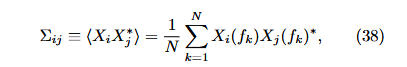

$$\Sigma_{ij}=<X_i,X_j>=\frac{1}{N}\sum_{k=1}^{N}X_i(f_k)X_j(f_k)^*$$


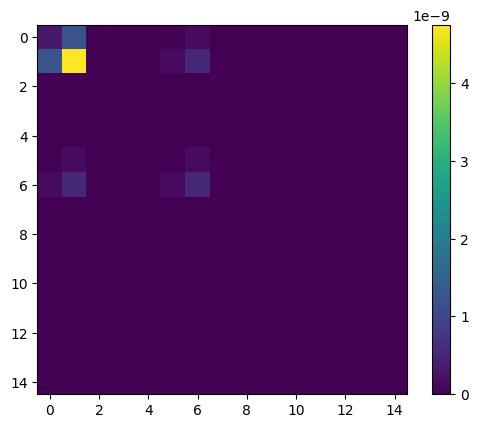

nanmask: 0


In [10]:
#find sigma
projs = 15
try:
    sigma = np.load('temp/sigma.npy')
except:
    sigma = np.zeros((projs,projs),dtype=complex)
    for i in tqdm(range(projs)):
        print(i)
        for j in range(projs):
            mult = X[i]*np.conj(X[j])
            nanmask = np.isnan(mult)
            infmask = np.isinf(mult)
            largemask = np.abs(mult)>1e4
            print(f"nanmask: {np.sum(nanmask)} and infmask: {np.sum(infmask)} and largemask: {np.sum(largemask)}")
            mult = mult[~nanmask & ~infmask & ~largemask]
            sigma[i,j] = np.mean(mult,dtype=complex)
    np.save('temp/sigma.npy',sigma)

    del infmask
    del mult

negative_mask = sigma.real < 0
sigma[negative_mask] = np.abs(sigma[negative_mask])

#display sigma as image
plt.imshow(np.abs(sigma))
plt.colorbar()
plt.show()

nanmask = np.isnan(sigma)
print(f"nanmask: {np.sum(nanmask)}")
del nanmask

In [ ]:
#Cholesky decomposition (maybe this should be put later)
if np.any(np.linalg.eigvalsh(sigma) <= 0):
    #modify sigma to be positive definite
    sigma = sigma + np.eye(sigma.shape[0])*np.mean(sigma.real)*1e-6
print()
L = np.linalg.cholesky(sigma)
invL = np.linalg.inv(L)

'test = np.dot(L,L.conj().T)\nplt.imshow(np.abs(test))\nplt.colorbar()\nplt.show()\n\ntest = np.linalg.inv(L)\nplt.imshow(np.abs(test))\nplt.colorbar()\nplt.show()'

# step 4: express mu

!!!TODO: am not completely sure this is the correct way to include alpha; validate

!!!TODO: are the units right?

!!!TODO: The Q function is aproximated atm, it should both be validated and potentially imporved (also are the scales correct?)


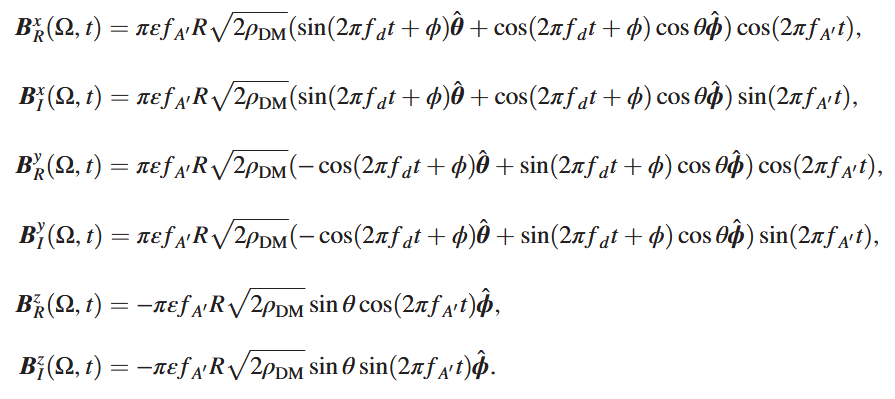

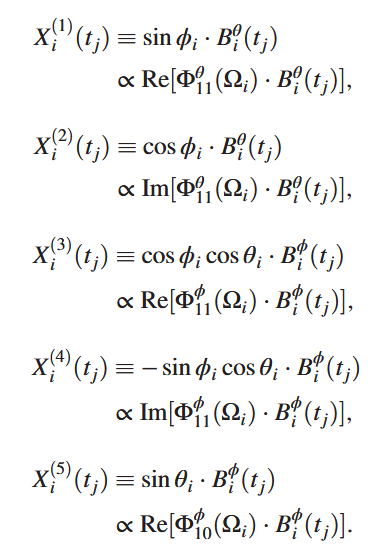

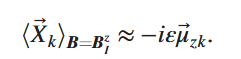

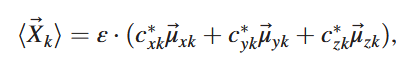

In [12]:
#the fourier transforms of the theoretical B fields has been worked out in Maple. Here it is imported and evaluated
consts = {
    "R": 6378000,
    "rho_DM": 4.8065299e-5, #!TEMP: currently set to 0.3 GeV/cm^3
    "theta": 0.82931413803612963043021475293659,#!TEMP: set to lattitude of Austria,
    "T": len(data_frequential)/freq,
    "f_d": 1.1574074074074074074074074074074e-5
}


def Q_factor(f):
    duration = len(data_frequential)/freq
    sampling = 1/freq
    return (1-np.exp(-2j*np.pi*f*duration))/(1-np.exp(-2j*np.pi*f*sampling))

def maple_parser(expr,freq,f__A,f__d,Delta_t,T,phi,theta):
    string = ""
    with open(expr,"r") as f:
        lines = f.readlines()
        for i, line in enumerate(lines):
            if i == 0:
                continue
            if i == 1:
                line = line[6:]#!validate
            if i == len(lines)-1:
                line = line[:-5]#!validate
            string += line.split('\n')[0]
        string = string.replace("Pi",str(np.pi))
        string = string.replace("I",str(1j))
        string = string.replace("exp","np.exp")
        string = string.replace("sin","np.sin")
        string = string.replace("cos","np.cos")
        string = string.replace("^","**")
        #num = eval(string)
    #return nu
    return string

temp = [
    compile(maple_parser("0_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("1_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("2_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("3_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("4_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("5_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("6_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("7_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("8_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
    compile(maple_parser("9_expression.m",0,0,0,0,0,0,0),"<string>","eval"),
]


def eval_maple(i,f,f__A,f__d,Delta_t,T,phi,theta):
    return eval(temp[i],{},{
        "f":f,
        "f__A":f__A,
        "f__d":f__d,
        "t__delta":Delta_t,
        "T":T,
        "phi":phi,
        "theta":theta,
        "np":np
    })

def B_func(f,f_A, coord_dir, theta, phi, external_params=consts):
    R = external_params["R"]
    rho_DM = external_params["rho_DM"]
    #theta = external_params["theta"]
    #T = external_params["T"]
    #var = 2*np.pi*f*R/(2-(2*np.pi*f*R)**2)
    #var *= np.sqrt(rho_DM/2)*np.sin(theta)*T
    f__d = external_params["f_d"]
    Delta_t = 1/freq
    T = len(data_frequential)/freq
    pre_fact = np.pi*f*R*np.sqrt(2*rho_DM)
    #!maple parser

    args = (f,f_A,f__d,Delta_t,T,phi,theta)
    if coord_dir == "x":
        #comp_theta_R = pre_fact*maple_parser("0_expression.m",*args)#! still not sure about the f__A
        comp_theta_R = pre_fact*eval_maple(0,*args)
        comp_phi_R = pre_fact*eval_maple(1,*args)
        comp_theta_I = pre_fact*eval_maple(2,*args)
        comp_phi_I = pre_fact*eval_maple(3,*args)
    if coord_dir == "y":
        comp_theta_R = pre_fact*eval_maple(4,*args)
        comp_phi_R = pre_fact*eval_maple(5,*args)
        comp_theta_I = pre_fact*eval_maple(6,*args)
        comp_phi_I = pre_fact*eval_maple(7,*args)
    if coord_dir == "z":
        comp_theta_R = -pre_fact*eval_maple(8,*args)
        comp_phi_R = -pre_fact*eval_maple(9,*args)
        comp_theta_I = 0
        comp_phi_I = 0
    val = [comp_theta_R+1j*comp_theta_I, comp_phi_R+1j*comp_phi_I]#returns in theta^ and phi^ direction
    return val


try:
    mu_vals = {
        "x": np.load("temp/mu_x.npy",mmap_mode='r+'),
        "y": np.load("temp/mu_y.npy",mmap_mode='r+'),
        "z": np.load("temp/mu_z.npy",mmap_mode='r+')
    }
except: 
    mux = np.zeros((15,datlen),dtype=complex)
    muy = np.zeros((15,datlen),dtype=complex)
    muz = np.zeros((15,datlen),dtype=complex)
    np.save("temp/mu_x.npy",mux)
    np.save("temp/mu_y.npy",muy)
    np.save("temp/mu_z.npy",muz)
    del mux
    del muy
    del muz
            
    mu_vals = {
        "x": np.load("temp/mu_x.npy",mmap_mode='r+'),
        "y": np.load("temp/mu_y.npy",mmap_mode='r+'),
        "z": np.load("temp/mu_z.npy",mmap_mode='r+')
    }

    def task(cart):
        for i_f in tqdm(range(datlen)):   
            fs = [freqs[i_f]-f_d, freqs[i_f], freqs[i_f]+f_d]
            for j in range(3):
                B = B_func(fs[j],freqs[i_f],cart,theta,phi)#!really unsure of the arguments here
                exp1 = np.sin(phi)*B[0]*np.cos(alpha)
                exp2 = np.cos(phi)*B[0]*np.cos(alpha)
                exp3 = np.cos(phi)*np.cos(theta)*B[1]*np.sin(alpha)
                exp4 = -np.sin(phi)*np.cos(theta)*B[1]*np.sin(alpha)
                exp5 = np.sin(theta)*B[1]*np.sin(alpha)
                mu_vals[cart][j*5,i_f] = exp1
                mu_vals[cart][j*5+1,i_f] = exp2
                mu_vals[cart][j*5+2,i_f] = exp3
                mu_vals[cart][j*5+3,i_f] = exp4
                mu_vals[cart][j*5+4,i_f] = exp5

                if np.any(np.isnan(mu_vals[cart][j*5:j*5+5,i_f])):
                    if i_f % 100000 == 0:
                        print(f"nan at {i_f} and {j}")

    #task("x")

    from multiprocessing import Pool    
    p = Pool(3)
    p.map(task,["x","y","z"])
    p.close()
    p.join()


# step 5: decompose to nu's, Y's and N's

In [13]:

#Y decomposition

try:
    Y = np.load('temp/Y.npy', mmap_mode='r+')
except:
    Y = np.dot(invL,X).T
    np.save('temp/Y.npy',Y)
    del Y
    Y = np.load('temp/Y.npy', mmap_mode='r+')

print("Y shape:",Y.shape)

nanmask = np.isnan(Y)
print(f"nanmask: {np.sum(nanmask)}")
del nanmask

Y shape: (16373077, 15)
nanmask: 0


In [14]:
#do nu decomposition

try:
    nu = np.load('temp/nu.npy',mmap_mode='r+')
except:
    nu = np.zeros((3,15,datlen),dtype=complex)
    carts = ["x","y","z"]
    for i in range(3):
        for j in tqdm(range(len(mu_vals[carts[i]][0]))):
            mu = mu_vals[carts[i]][:,j]
            nu[i,:,j] = np.dot(invL,mu)
        if np.isnan(nu[i]).any():
            print(f"nan in nu at {i}")
        if i % 100000 == 0:
            print(f"{i}: {nu[i]} ",end='\r')

    print()
    np.save('temp/nu.npy',nu)
    print(nu)
    del nu
    nu = np.load('temp/nu.npy',mmap_mode='r+')

try:
    del L
except:
    pass

gc.collect()

nanmask = np.isnan(nu)
print(f"nanmask: {np.sum(nanmask)}")
del nanmask

nanmask: 0


In [15]:
#put into N
N = nu.T
del nu
gc.collect()

0

# step 6: decompose further to Z

In [16]:
#numpy concatenation doesnt support memmap, so this is an "array wrapper" for a concatenated memmap array
class array_concatenated():
    def __init__(self,arrays):
        self.arrays = arrays
        self.shape = (len(arrays),len(arrays[0]))
    def __getitem__(self,i):
        arr_i = i//len(self.arrays[0])
        arr_j = i%len(self.arrays[0])
        return self.arrays[arr_i][arr_j]
    def __setitem__(self,i,val):
        arr_i = i//len(self.arrays[0])
        arr_j = i%len(self.arrays[0])
        self.arrays[arr_i][arr_j] = val
    def __len__(self):
        return len(self.arrays)*len(self.arrays[0])

In [27]:

chunksize = 1000000
gc.collect()
try:
    u_parts = [np.load(f"temp/U/{i}.npy",mmap_mode='r+') for i in range(0,datlen//1000000)]
    U = array_concatenated(u_parts)
    S = np.load('temp/S.npy',mmap_mode='r+')
    with open("temp/U_line_number.txt","r") as f:
        line_number = int(f.read())
    if line_number != -1:
        raise FileNotFoundError
except FileNotFoundError:
    n = N[0]
    u,s,v = np.linalg.svd(n)
    shape = [datlen] + list(u.shape)
    try:
        os.mkdir("temp/U")
    except FileExistsError:
        pass
    for j,i in tqdm(enumerate(range(0,datlen,chunksize)),desc="writting U array"):
        existing= os.listdir("temp/U")
        if f"{j+1}.npy" in existing and f"{j}.npy" in existing:
            continue
        shape_dummy = [min(chunksize,datlen-i)] + list(u.shape)
        dummy = np.zeros(shape_dummy,dtype=complex)
        np.save(f"temp/U/{j}.npy",dummy)
        del dummy
        gc.collect()
    u_parts = [np.load(f"temp/U/{i}.npy",mmap_mode='r+') for i in range(0,datlen//chunksize+1)]
    U = array_concatenated(u_parts)
    del u_parts
    gc.collect()
    shape = [datlen] + list(s.shape)
    mock_S = np.zeros(shape,dtype=complex)
    np.save('temp/S.npy',mock_S)
    del mock_S
    gc.collect()
    
    S = np.load('temp/S.npy',mmap_mode='r+')

    #The above, but multi-threaded
    def job(i):
        U[i],S[i],_ = np.linalg.svd(N[i])
        if i%100000==0: 
            print(f"{i}: {S[i]} ",end='\r')
            for a in U.arrays:
                a.flush()
            S.flush()
            gc.collect()
    #import multiprocessing
    #with multiprocessing.Pool(processes=4) as pool:
    #    pool.map(job,range(datlen))
    print()
    print(U)   
    print(S)
    #make line number file
    if os.path.exists("temp/U_line_number.txt"):
        with open("temp/U_line_number.txt","r") as f:
            line_number = int(f.read())
    else:
        with open("temp/U_line_number.txt","w") as f:
            f.write("0")
        line_number = 0

    for i in tqdm(range(line_number,datlen),desc="writting U array"):
        job(i)
        if i % chunksize == 0:
            with open("temp/U_line_number.txt","w") as f:
                f.write(str(i))
    with open("temp/U_line_number.txt","w") as f:
        f.write("-1")
    del N   

    gc.collect()


In [ ]:
try:
    Z = np.load('temp/Z.npy',mmap_mode='r+')
except:

    Z = np.zeros([datlen,15],dtype=complex)
    np.save('temp/Z.npy',Z)
    del Z
    Z = np.load('temp/Z.npy',mmap_mode='r+')
    for i in tqdm(range(datlen)):
        Z[i] = np.dot(U[i].conj().T,Y[i])

In [ ]:
del U
gc.collect()

# step 7: Given the theoretically marginalized distribution for $p(\epsilon|Z)$, insert $Z$ and integrate to find the p=0.05 confidence $\epsilon$ bound.
!!!TODO: At the moment this is done numerically, which is super inefficient. An analytical integral would majorly decrease turn-arround time for results.

$$p(\varepsilon | \mathcal{Z}) = \mathcal{N} \sqrt{\sum_m \frac{4 \varepsilon^2 s_m^4}{\left(3 + \varepsilon^2 s_m^2\right)^2}} \times
\prod_m \frac{1}{3 + \varepsilon^2 s_m^2} \exp \left( - \frac{3 |z_m|^2}{3 + \varepsilon^2 s_m^2} \right)$$
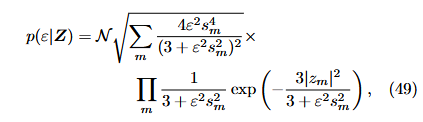


In [20]:
#step 7: define and normalize p
#$$p(\varepsilon | \mathcal{Z}) = \mathcal{N} \sqrt{\sum_m \frac{4 \varepsilon^2 s_m^4}{\left(3 + \varepsilon^2 s_m^2\right)^2}} \times\prod_m \frac{1}{3 + \varepsilon^2 s_m^2} \exp \left( - \frac{3 |z_m|^2}{3 + \varepsilon^2 s_m^2} \right)$$
from numba import jit
@jit(nopython=True)
def p(epsilon, Z, S,N):
    
    #square root term
    square_root = 0
    for m in range(chans):
        square_root += 4*epsilon**2*S[m]**4/(3+epsilon**2*S[m]**2)**2
    square_root = np.sqrt(square_root)

    #product term
    product = 1
    for m in range(chans):
        product *= 1/(3+epsilon**2*S[m]**2)

    #exponential term
    for m in range(chans):
        product *= np.exp(-3*np.abs(Z[m])**2/(3+epsilon**2*S[m]**2))

    return square_root*product

#find S's as diagonal of S
"""s = np.zeros((datlen,chans),dtype=complex)
for i in tqdm(range(datlen)):
    s[i] = np.diag(S[i])
del S"""

#find Z's as components of Z
"""z = np.zeros((datlen,chans),dtype=complex)
for i in tqdm(range(datlen)):
    z[i] = Z[i]
del Z
gc.collect()"""
#more efficiently:
z = Z
del Z





$$\int_0^{\hat{\varepsilon}} d\varepsilon \, p(\varepsilon | \mathcal{Z}) = 0.95$$

In [21]:
ep_res = 5000
def setEp(ep_max, ep_min=1e-11):
    #do 50% of the space in low-res, 50% in high-res
    cut = 0.7
    #ep_low = np.linspace(0.0001,ep_max*cut,ep_res//10)
    #ep_high = np.linspace(ep_max*cut,ep_max,ep_res)
    #just do logspace
    #ep = np.logspace(np.log10(ep_min),np.log10(ep_max),ep_res)
    #just do linspace
    ep = np.linspace(ep_min,ep_max,ep_res)
    return ep#np.hstack([ep_low,ep_high])
#epsilon = np.linspace(0.0001, 100000000000, ep_res)
epsilon = setEp(1e-2)
from multiprocessing import Pool
import h5py
gc.collect()
gc.collect()

try:
    #p_vals = np.load('temp/p_vals.npy')
    """try:
        shutil.move('temp/p_vals.h5','p_vals.h5')
    except FileNotFoundError:
        pass
    with h5py.File('p_vals.h5','r') as f:
        p_vals = f['p_vals'][:]
        eps_max = f['eps_max'][:]
    shutil.move('p_vals.h5','temp/p_vals.h5')"""
    #p_vals = np.memmap('temp/p_vals.npy',dtype=complex,mode='r+',shape=(datlen,len(epsilon)))
    #eps_max = np.memmap('temp/eps_max.npy',dtype=complex,mode='r+',shape=(datlen))
    #e_hats = np.memmap('temp/epsilon_hats.npy',dtype=complex,mode='r+',shape=(datlen))
    e_hats = np.load('temp/epsilon_hats.npy',mmap_mode='r+')
except:

    
    #step 8: solve integral 50 (variable in frequency) to find epsilon hat
    #$$\int_0^{\hat{\varepsilon}} d\varepsilon \, p(\varepsilon | \mathcal{Z}) = 0.95$$

    #find value of p over epsilon
    #p_vals = np.zeros((datlen,len(epsilon)))

    #instantiate p_vals and eps_max as a memmap
    #dummy = np.zeros((datlen,len(epsilon)),dtype=complex)#! this one is impossible
    #np.save('temp/p_vals.npy',dummy)
    #del dummy
    #p_vals = np.memmap('temp/p_vals.npy',dtype=complex,mode='r+',shape=(datlen,len(epsilon)))
    #dummy = np.zeros(datlen,dtype=complex)
    #np.save('temp/eps_max.npy',dummy)
    #del dummy
    #eps_max = np.memmap('temp/eps_max.npy',dtype=complex,mode='r+',shape=(datlen))

    dummy = np.zeros(datlen,dtype=complex)
    np.save('temp/epsilon_hats_temp.npy',dummy)
    del dummy
    #e_hats = np.memmap('temp/epsilon_hats_temp.npy',dtype=complex,mode='r+',shape=(datlen))
    e_hats = np.load('temp/epsilon_hats_temp.npy',mmap_mode='r+')

    
    def job(i):
        if i%1000==0: print(f"{i}, ", end="")
        sl = np.diag(S[i])
        zl = z[i]
        #norm = norms[i]
        def do_job(epl):
            def p(ep):
                #summations and products are over polarizations (1d for now)

                # Compute the summation term
                #if ep is array, vectorize
                #sum_term = lambda ep: 4 * ep**2 * sl**4 / (3 + ep**2 * sl**2)**2
                eps = ep**2
                @np.vectorize
                def sum_term(eps):
                    return np.sum(4 * eps * sl**4 / ((3 + (eps * sl**2))**2))
                st = sum_term(eps)
                #plt.plot(ep,st)
                #plt.title(f"Sum term at {i}")
                #plt.show()
                
                # Compute the product term
                @np.vectorize
                def product_term(eps):
                    return np.prod(
                        (1 / (3+(eps*sl**2))) *
                        np.exp(-3 * np.abs(zl)**2 / (3 + (eps * sl**2)))
                    )
                pt = product_term(eps)
                #plt.plot(ep,pt)
                #plt.title(f"Product term at {i}")
                #plt.show()
                
                # Combine terms with normalization constant
                normalization = np.sqrt(st)
                return normalization * pt

            p_e = p(epl)
            #norm
            #plt.plot(epsilon,p_e)
            #plt.show()
            t = np.trapezoid(p_e,epl)
            if t==0:
                print(f"Zero integral at {i}")
                return p_e
            p_e /= t
            return p_e
        p_e = do_job(epsilon)
        if np.max(p_e)==0:
            print(f"Zero max at {i}")
            e_hats[i] = np.nan
            return
            #return (p_e, epsilon[-1])
        if np.any(np.isnan(p_e)):
            print(f"NaN at {i}")
            e_hats[i] = np.nan
            return
            #return (p_e, epsilon[-1])
        
        #temp plot
        if np.random.rand()<0.0001:
            plt.plot(epsilon,p_e)
            plt.title(f"p(epsilon) at {i}")
            plt.show()
        
        last_pe_ratio = p_e[-1]/np.max(p_e)
        #see if it has flattened out
        ep_stack= [epsilon]
        p_e_stack = [p_e]
        while last_pe_ratio>0.001:
            #ep_new = np.linspace(ep_new[0],ep_new[-1]*2,ep_res)
            ep_stack.append(setEp(ep_stack[-1][-1]*10,ep_stack[-1][-10]))
            p_e_stack.append(do_job(ep_stack[-1]))
            last_pe_ratio = p_e_stack[-1][-1]/np.max(p_e_stack[-1])
            #print(f"Last pe ratio: {last_pe_ratio}")
        if len(ep_stack)>1:
            ep_new = np.hstack(ep_stack)
            sort_mask = np.argsort(ep_new)
            p_e = np.hstack(p_e_stack)
            p_e = p_e[sort_mask]
            epsilon_local = ep_new
        else:
            epsilon_local = epsilon
        #if ep_new[-1]>epsilon[-1]:
            #print("Ratio solved")
        #random condition to plot
        #if np.random.rand()<0.0001:
        #    #plt.plot(ep_new,p_e)
        #    #plt.show()
        #return (p_e, ep_new[-1])
        #p_vals[i] = p_e
        #eps_max[i] = eps_max[-1]
        #!instead of saving these, process them instantly such that the memory is freed
        #p_e = p_vals[i]
        
        trap_area = np.array([(p_e[j] + p_e[j + 1]) * (epsilon_local[j + 1] - epsilon_local[j]) / 2 for j in range(len(epsilon_local) - 1)],dtype=complex).real
        for j in range(1, len(trap_area)):
            #loop through the last areas and fin the latest non-nan value to add
            for k in range(j):
                if not np.isnan(trap_area[j - k - 1]):
                    #print(".")
                    trap_area[j] += trap_area[j - k - 1]
                    break
        #and then just find the index closest to 0.95
        #epsilon = np.linspace(0.0001, eps_max[i], ep_res)
        
        e_hat = epsilon_local[np.argmin(np.abs(p_e - 0.95))]
        e_hats[i] = e_hat
    dl = datlen
    print(f"Dataset len = {dl}")
    with Pool(processes=16) as pool:
        pool.map(job, range(dl), chunksize=dl//16//64)
    #    #p_vals, eps_max = zip(*result)
    #!temp
    #[job(i) for i in range(dl)]
    #p_vals, eps_max = zip(*result)
    gc.collect()
    print("Loop done")
    np.save('temp/epsilon_hats.npy',e_hats)
    del e_hats
    os.remove('temp/epsilon_hats_temp.npy')
    #e_hats = np.memmap('temp/epsilon_hats.npy',dtype=complex,mode='r+',shape=(datlen))
    e_hats = np.load('temp/epsilon_hats.npy',mmap_mode='r+')
    
    #print([print(p_vals[i].max()) for i in range(dl)])
    #print([print(p_vals[i].min()) for i in range(dl)])

    #saving by h5py
    #with h5py.File('p_vals.h5','w') as f:
    #    f.create_dataset('p_vals',data=p_vals)
    #    f.create_dataset('eps_max',data=eps_max)
    #move
    
    #shutil.move('p_vals.h5','temp/p_vals.h5')





Dataset len = 16373077
0, 15989000, 

ValueError: operands could not be broadcast together with shapes (2,) (3,3) 

In [1]:
#plot epsilon hats as a function of frequency
fig, ax = plt.subplots(figsize=(15,5))
#exclude freq ~0
freqs = freqs[:dl]
pX = freqs[np.all([freqs>0.000001],axis=0)]
pE = e_hats[np.all([freqs>0.000001],axis=0)]
#pE[pX>0.15885] *= 10
#pE[pE>1e11] = np.nan
#pE[np.all([pE<3e9,pX>0.14])] = np.nan
plt.scatter(pX,pE,s=10,alpha=0.5)    
#plt.ylim(0.4745,0.4746)
#log scale
plt.loglog()
# plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Epsilon hat')
plt.show()

NameError: name 'plt' is not defined